In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [12]:
node_counts = {
    "test1.json" : 1000,
    "test2.json" : 10000,
    "test3.json" : 100000,
    "test4.json" : 1000000,
    "test5.json" : 10000000,
}

bucket_counts = {
    "100" : 100,
    "10k" : 10000,
    "1k" : 1000,
    "5k" : 5000,
    "20k" : 20000,
    "40k" : 40000,
    "70k" : 70000
}

test_names = [
    "simple bintree test",
    "continuous bintree test",
    "map test",
    "unordered map test",
     "deep umap test (100 buckets)",
     "deep umap test (1000 buckets)",
     "deep umap test (5000 buckets)",
     "deep umap test (10000 buckets)",
     "deep umap test (20000 buckets)",
     "deep umap test (40000 buckets)",
     "deep umap test (70000 buckets)"
    ]

class TestData:
    def __init__(self, test_name, node_count, elapsed, instructions, cycles, branches, branch_misses):
        self.warmup = 1000
        self.test_name = test_name
        self.node_count = node_count
        self.elapsed = elapsed
        self.instructions = instructions
        self.cycles = cycles
        self.branches = branches
        self.branch_misses = branch_misses
        self.per_second = 1/elapsed
        self.ci_ratio = cycles/instructions
        if branches != 0 and branch_misses !=0:
            self.bm_ratio = branch_misses/branches
        else:
            self.bm_ratio = 1

    def copy(other):
        return TestData(other.test_name, other.node_count, other.elapsed, other.instructions, other.cycles, other.branches, other.branch_misses)


    def get_value(self, value_string):
        match value_string:
            case "cycles": return self.cycles
            case "elapsed": return self.elapsed
            case "instructions": return self.instructions
            case "branches": return self.branches
            case "branch misses": return self.branch_misses
            case "search/s": return self.per_second
            case "cycles/ins": return self.ci_ratio
            case "misses/branch" : return self.bm_ratio
        raise ValueError("Bad param: "+value_string)

    def get_array(self):
        return [self.elapsed, self.per_second, self.instructions, self.cycles, self.ci_ratio, self.branches, self.branch_misses, self.bm_ratio]

dir_name = "records"

valid_attributes = [
    "cycles", "elapsed", "instructions", "branches", "branch misses", "search/s", "cycles/ins", "misses/branch"
]

test_results = {} # key: node_count + test_name

def parse_data():
    dir_id= os.fsencode(dir_name)
    im_data = {} # key: node_count + test_name

    for n in node_counts:
        im_data[node_counts[n]] = {}
        for name in test_names:
            im_data[node_counts[n]][name] = []

    for n in node_counts:
        test_results[node_counts[n]] = {}
    
    for buckets in os.listdir(dir_id):
        str_buckets = buckets.decode()
        dmap_bcount = bucket_counts[str_buckets]
        bucket_dir = os.path.join(dir_name, buckets.decode())
        bucket_id = os.fsencode(bucket_dir)
        for son_of_bucket_named_jay in os.listdir(bucket_id):
            filename = son_of_bucket_named_jay.decode()
            fpath = os.path.join(bucket_dir, filename)
            parsed = json.loads(open(fpath).read())["results"]
            for r in parsed:
                if r["name"] == "deep umap test": # there is only one per deep map
                    testname = r["name"]+" (" +str(dmap_bcount)+" buckets)"
                    data = TestData(testname,
                                    node_counts[filename],
                                    r["median(elapsed)"],
                                    r["median(instructions)"],
                                    r["median(cpucycles)"],
                                    r["median(branchinstructions)"],
                                    r["median(branchmisses)"])
                    test_results[node_counts[filename]][testname] = data
                else: # store others for averaging
                    testname = r["name"]
                    data = TestData(testname,
                                    node_counts[filename],
                                    r["median(elapsed)"],
                                    r["median(instructions)"],
                                    r["median(cpucycles)"],
                                    r["median(branchinstructions)"],
                                    r["median(branchmisses)"])
                    im_data[node_counts[filename]][testname].append(data)
                
    for n in im_data: # get average of medians
        avg_elapsed = 0
        avg_instructions = 0
        avg_cycles = 0
        avg_branches = 0
        avg_branch_misses = 0
        nm=""
        for name in im_data[n]:
            nm = name
            name = im_data[n][name]
            if len(name) == 0:
                continue
            for d in name:
                data = d
                avg_elapsed += data.elapsed
                avg_instructions += data.instructions
                avg_cycles += data.cycles
                avg_branches += data.branches
                avg_branch_misses += data.branch_misses
            
            avg_elapsed /= len(name)
            avg_instructions /= len(name)
            avg_cycles /= len(name)
            avg_branches /= len(name)
            avg_branch_misses /= len(name)

            avg_data = TestData(nm,
                                n,
                                max(avg_elapsed, 0),
                                max(avg_instructions, 0),
                                max(avg_cycles, 0),
                                max(avg_branches, 0),
                                max(avg_branch_misses, 0))

            test_results[n][nm] = avg_data


parse_data()


def show_plot(node_count, value_string, index = [0,1,2,3,4,5,6,7,8,9,10]):
    collections = ["Simple Binary Tree",
        "Contiguous Binary Tree",
        'std::map',
        'std::unordered_map Dynamic',
        "std::unordered map With 100 Buckets",
        "std::unordered map With 1000 Buckets",
        "std::unordered map With 5000 Buckets",
        "std::unordered map With 10000 Buckets",
        "std::unordered map With 20000 Buckets",
        "std::unordered map With 40000 Buckets",
        "std::unordered map With 70000 Buckets"
        ]

    colors = ['red', 'chocolate',  'orange' ,'lime', 'yellowgreen', 'black',  'gray', 'orchid', 'darkturquoise', 'blue', "indigo"]
    speed = [-1] * len(collections)
    for d in test_results[node_count]:
        d = test_results[node_count][d]
        speed[test_names.index(d.test_name)] = d.get_value(value_string)

    out_coll = []
    out_s = []
    out_c = []
    for c in collections:
        if collections.index(c) in index:
            out_coll.append(c)
            out_s.append(speed[collections.index(c)])
            out_c.append(colors[collections.index(c)])
    
    plt.figure(figsize=(6, 8), layout="tight")
    plt.bar(out_coll, out_s, color=out_c)
    plt.xticks(rotation=75)
    plt.title(value_string + " (node count: "+str(node_count)+")")
    plt.show()



# Benchmark of search times in various data structures

The benchmark looks at the search speeds of the following data structures:

- A simple binary tree
- A binary tree which stores its data in a contiguous array
- std::map (typically implemented as a red-black tree)
- std::unordered_map with the following bucket counts:
    - The dynamically chosen bucket count
    - 100 buckets
    - 1000 buckets
    - 5000 buckets
    - 10000 buckets
    - 20000 buckets
    - 40000 buckets
    - 70000 buckets

Each data structure was examined under the following loads:

- 1000 Nodes
- 10000 Nodes
- 100000 Nodes
- 1000000 Nodes
- 10000000 Nodes

One Node contains a single key of type uint64_t, and two pointers t its child nodes. These nodes were also used in data structures which do not require them for the sake of consistency.

# Benchmark enviroment
The benchmark was performed in the following enviroment:

- Processor: 11th Gen Intel Core i3
    - Clock speed: 2.00 GHz
    - cores: 4
    - logical units: 2
    - Cache: 320KB/5MB/8MB
- Operating system: Ubuntu under WSL
- Language: C++ compiled with GCC

# Software Libraries
- [nanobench](https://nanobench.ankerl.com/index.html): Used for performing the benchmark. Its Random number generation capabilities were also used for load generation
- C++ standard library: The [std::map](https://en.cppreference.com/cpp/container/map) and [std::unordered_map](https://en.cppreference.com/cpp/container/unordered_map) data structures being tested are from this library.

# The Two Trees
Two of the data strutures are my own implementation.
They are both binary search trees with a very simple interface:

- The constructor takes an std::vector of keys and generates a tree from it.
- The Search method takes a key and returns a pointer to the desired Node

The only difference between the two trees is their methid if storage. The BinTree class simply allocates Nodes on the heap, whereas the BinTreeCont class stores them using an std::vector.

# Performing the Benchmark
The structure of the benchmark is as follows:

The program takes 6 arguments:

- The number of Nodes to generate
- The seed used for generating Nodes
- The seed used for generatin search keys
- The number of iterations the benchmark performs
- The number of buckets the std::unordered_map with the custom bucket count will have
- The file to output the results to

If no parameters are given, the preogram will continue with default values.

The program then generates the test cases, and performs the bencmark, outputting the result in JSON format.

A warmup period of 1000 iterations take place before each test to ensure correct measurements.

Using a bash script, the program can be run several times with different configurations.

The std::unordered_map with the custom bucket count was only tested once per bucket count and node count combination. This was done due to the lower bucket counts causing very long run times. All other data structures, including the dynamically sizzed std::unordered_map were tested several times, and their results are an average of the median of each test.

# Units of measurement
- searches per second (search/s)
- search time in seconds (elapsed)
- CPU instructions per search (instructions)
- CPU cycles per search (cycles)
- CPU cycles per instruction (cycles/ins)
- branch instructions (branches)
- branch misses (ranch misses)
- branch misses per branch instruction (misses/branch)



# Results

The results show that an std::unordered_map with more buckets than stored elements can find an element in near-constant time, vastly outperforming any other data structure. On the other hand, if the bucket count becomes too low, the search speed plummets.
The dynamic std::unordered_map matches the bucket count to its size really well, consistently outdoing the other data structures.

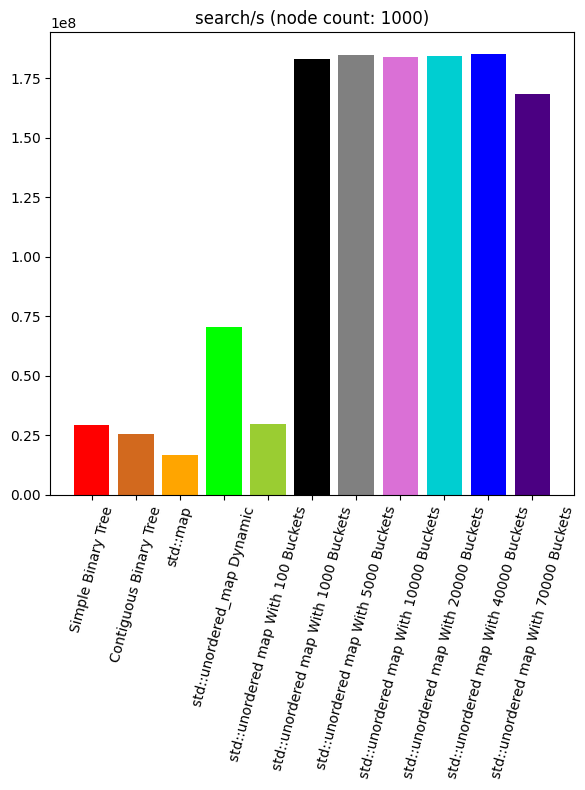

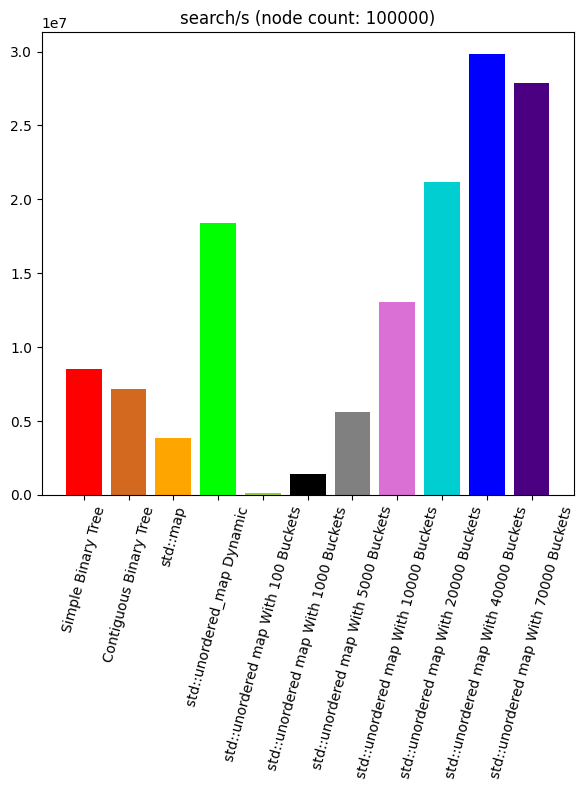

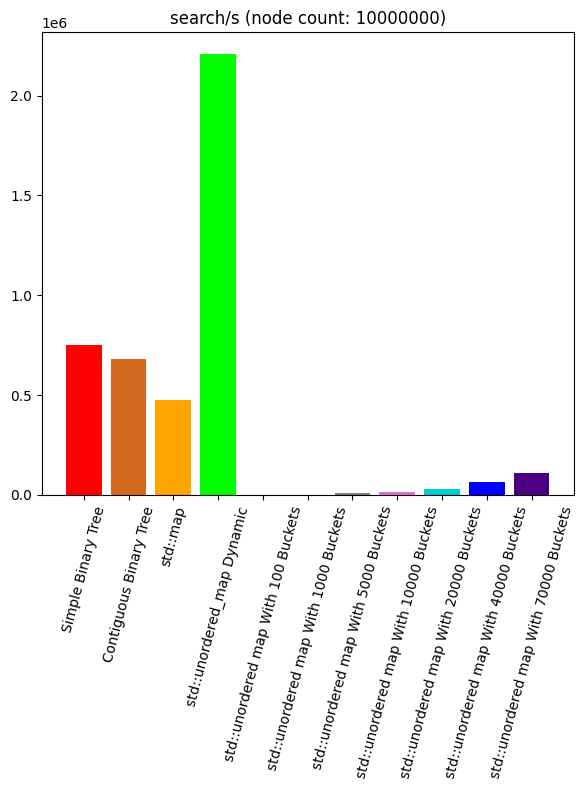

In [3]:
show_plot(1000, "search/s")
show_plot(100000, "search/s")
show_plot(10000000, "search/s")

My simple binary tree seems to be consistently about twice as fast as std::map. The exact reasons for this are unclear.

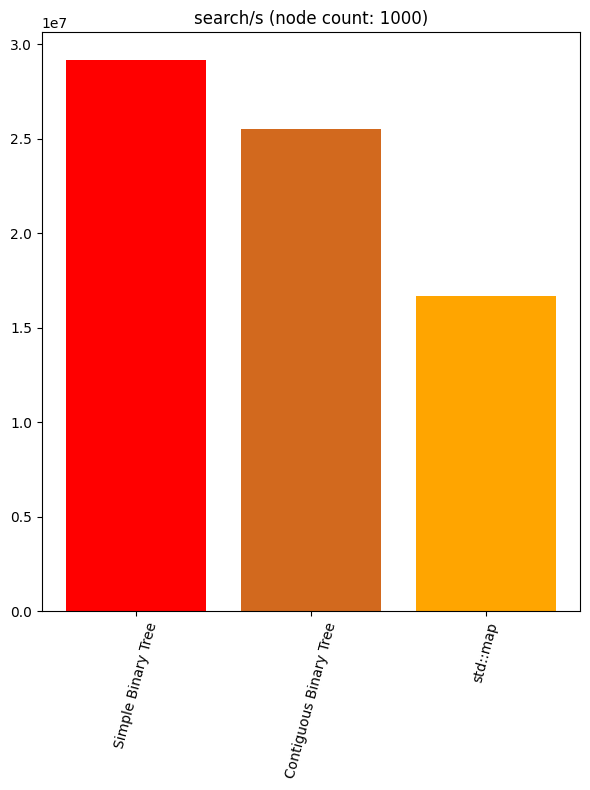

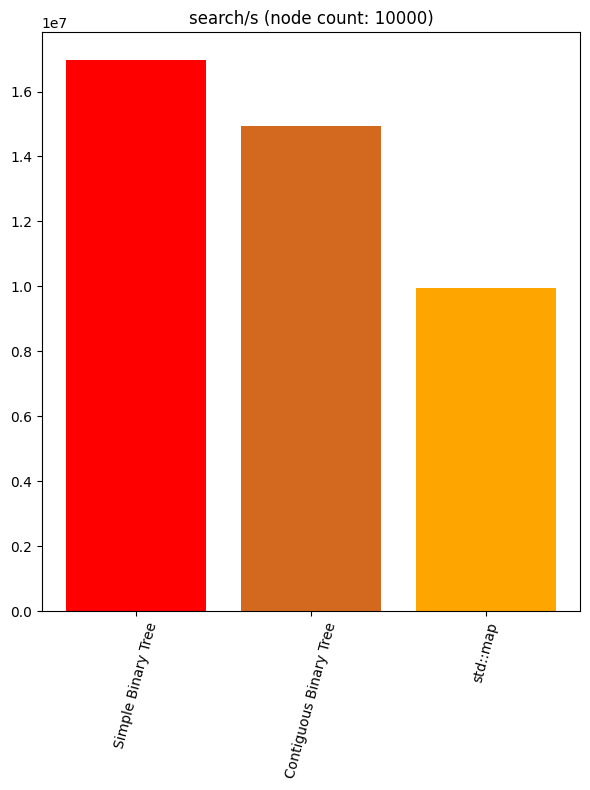

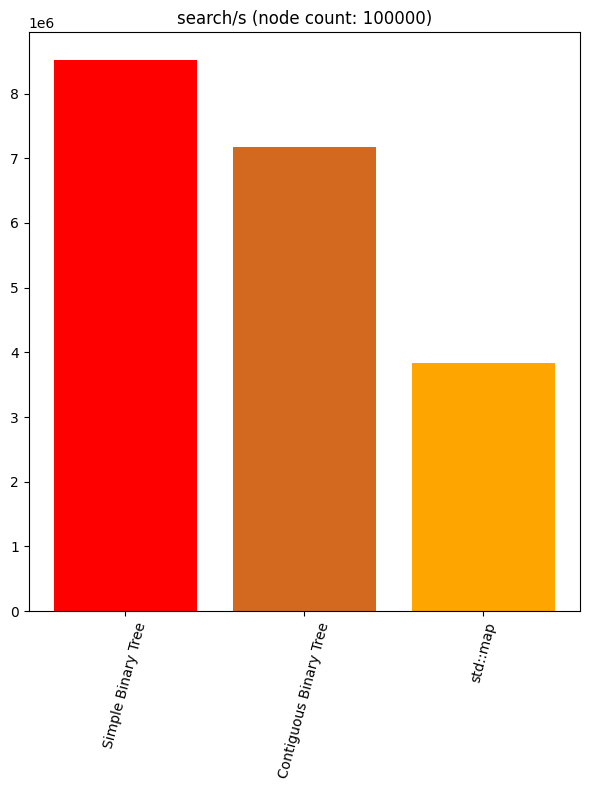

In [4]:
show_plot(1000, "search/s", [0,1,2])
show_plot(10000, "search/s", [0,1,2])
show_plot(100000, "search/s", [0,1,2])

At low bucket counts compared to the number of stored elements, the number of branches during an std::unordered_map's search skyrockets. These branches however, are extremely consistent, the branch predictor almost never makes a mistake. This makes sense, as with a bucket count his low, most of the search is spent traversing a linked list. Compared to this, std::map misses about 10% of its branches, indicating that something more complex is going on behind the scenes.

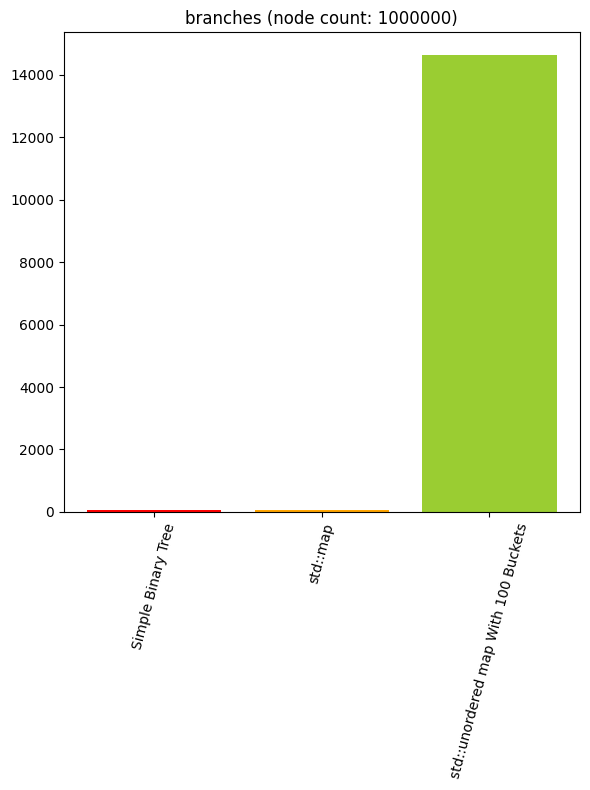

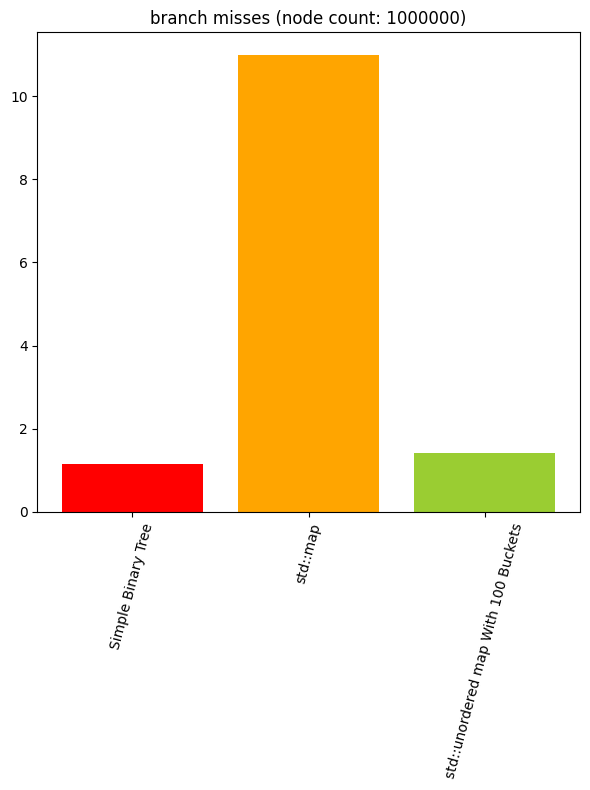

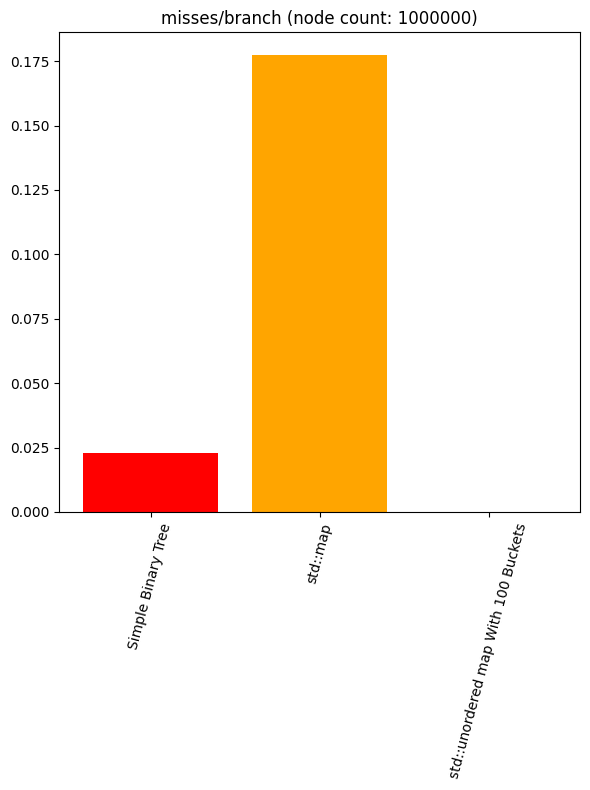

In [5]:
show_plot(1000000, "branches", [0,2,4])
show_plot(1000000, "branch misses", [0,2,4])
show_plot(1000000, "misses/branch", [0,2,4])

Similarly, we can see that std::map not only performs more work during a search than my own tree, but the work it performs also seems more complex, as each instruction take more cycles. This seems to stay consistent regardless otree size.

In this chart we can also see that BinTreeCont storing nodes contiguously seems to come with a slight overhead, despite the search operation being identical to what BinTree performs.

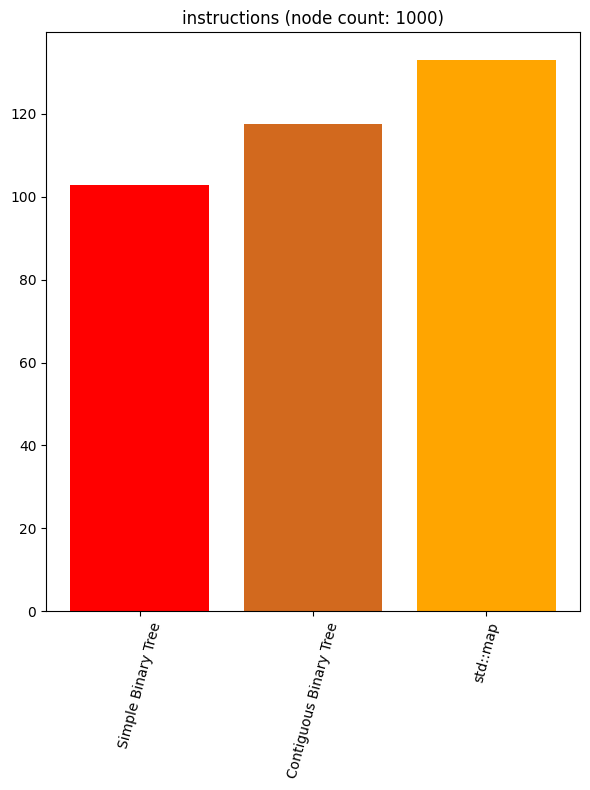

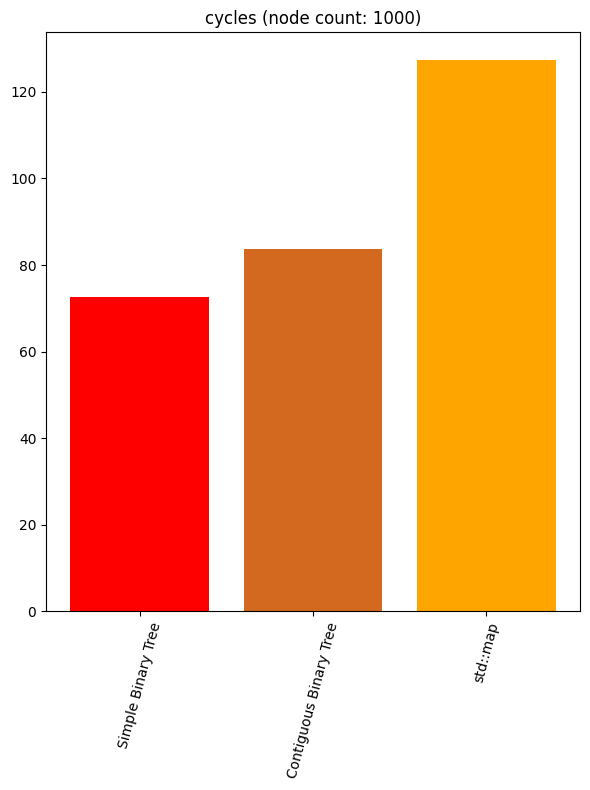

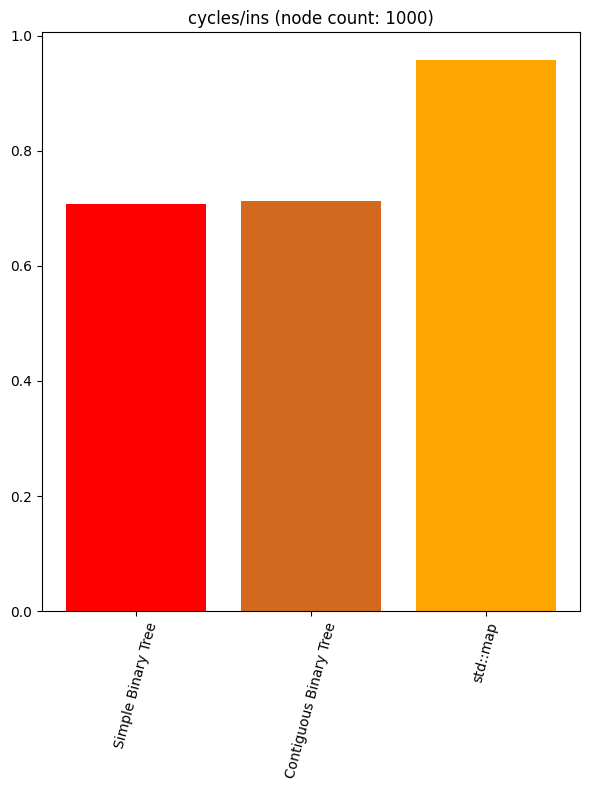

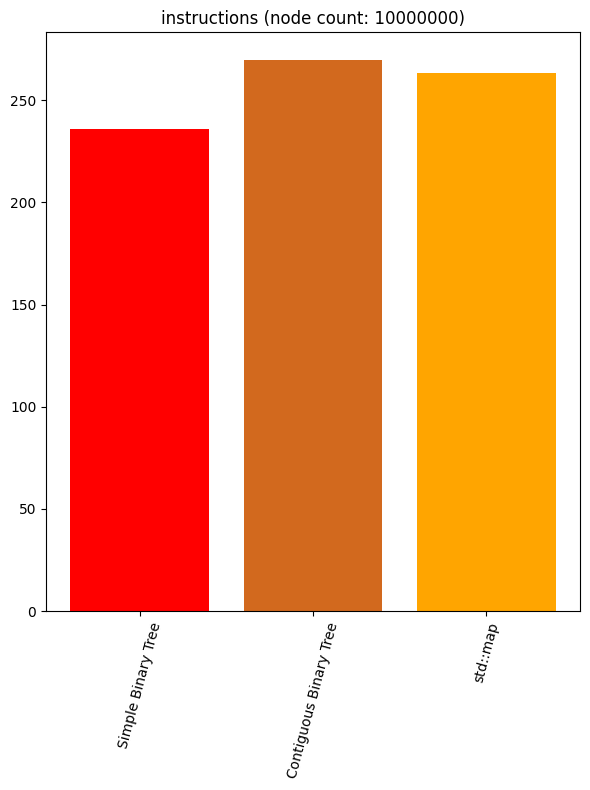

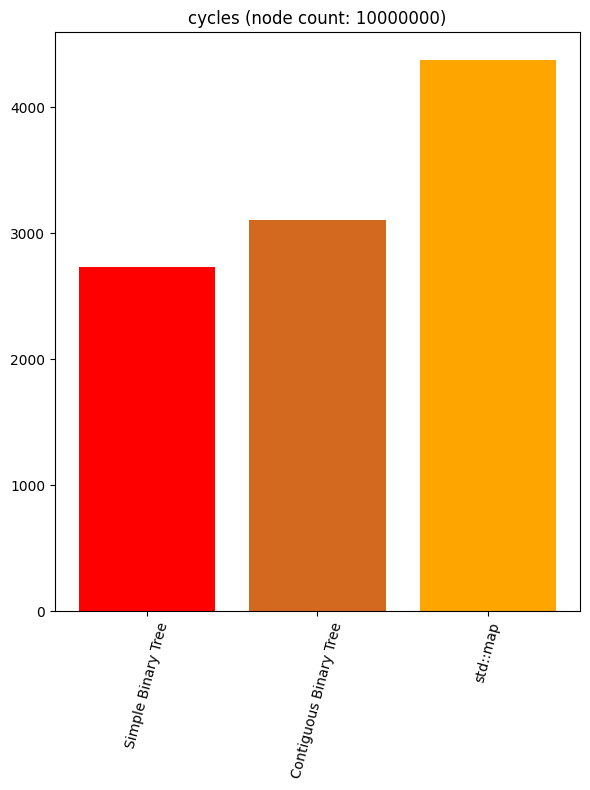

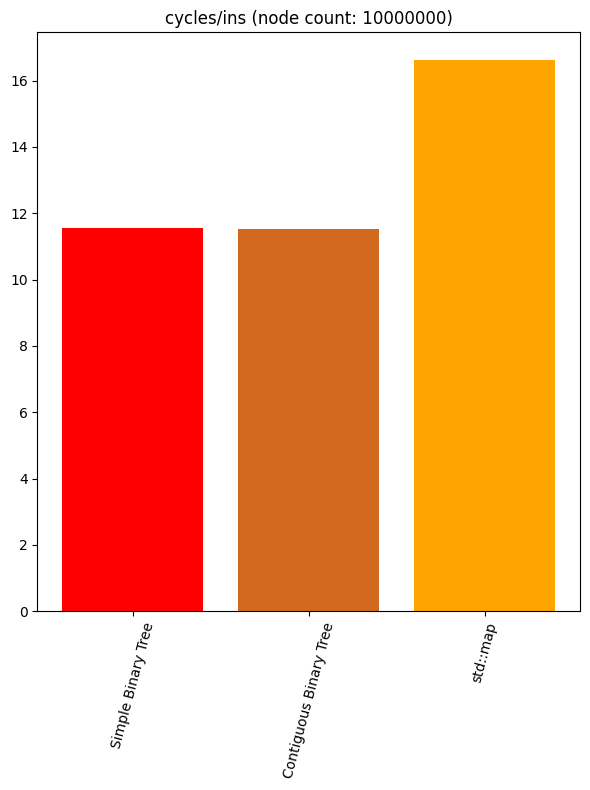

In [6]:
show_plot(1000,"instructions", [0,1,2])
show_plot(1000,"cycles", [0,1,2])
show_plot(1000,"cycles/ins", [0,1,2])
show_plot(10000000,"instructions", [0,1,2])
show_plot(10000000,"cycles", [0,1,2])
show_plot(10000000,"cycles/ins", [0,1,2])

# Conclusion
Overall, std::unordered_map seems to scale really well regardless of how much data it needs to store, and consistently yields great results. Finding out that a simple binary tree is faster than std::map definitely came as a surprise, the exact reason behind that needs further investigation.

The benchmark suite could definitely use some improvements, currently there is a lot of repeated code and hard-coded values both in the software itself and the scriptused to run it. Ironing out these details would allow for more precise control over the ways the benchmark could be performed.


In [7]:
def show_plot_special():
    collections = ["1000 Nodes",
        "10000000 Nodes"
        ]

    colors = ['red', 'chocolate',  'orange' ,'lime', 'yellowgreen', 'black',  'gray', 'orchid', 'darkturquoise', 'blue', "indigo"]
    speed = [-1] * len(collections)
    names = ["Simple Binary Tree",
        "Contiguous Binary Tree",
        'std::map',
        'std::unordered_map Dynamic',
        "std::unordered map With 100 Buckets",
        "std::unordered map With 1000 Buckets",
        "std::unordered map With 5000 Buckets",
        "std::unordered map With 10000 Buckets",
        "std::unordered map With 20000 Buckets",
        "std::unordered map With 40000 Buckets",
        "std::unordered map With 70000 Buckets"
        ]
    
    out_coll = []
    out_s = []
    out_c = []
    data = []
    for n in test_names:
        out_coll = []
        out_s = []
        out_c = []
        
        for t in test_results[1000]:
            t = test_results[1000][t]
            if t.test_name == n:
                out_coll.append(collections[0])
                out_s.append(t.elapsed)
                out_c.append(colors[test_names.index(t.test_name)])
        for t in test_results[10000000]:
            t = test_results[10000000][t]
            if t.test_name == n:
                out_coll.append(collections[1])
                out_s.append(t.elapsed)
                out_c.append(colors[test_names.index(t.test_name)])
        data.append([names[test_names.index(n)], out_s[0], out_s[1]])
        
#        plt.figure(figsize=(6, 8), layout="tight")
  #      plt.bar(out_coll, out_s, color=out_c)
   #     plt.xticks(rotation=75)
    #    plt.title(names[test_names.index(n)])
#        plt.show()

    frame = pd.DataFrame(data)
    frame.columns = ["Search time in seconds","1000 Nodes", "10000000 Nodes"]
    display(frame)

show_plot_special()

,Search time in seconds,1000 Nodes,10000000 Nodes
0,Simple Binary Tree,3.427458e-08,1.333370e-06
1,Contiguous Binary Tree,3.916635e-08,1.463927e-06
2,std::map,6.003871e-08,2.100107e-06
3,std::unordered_map Dynamic,1.422204e-08,4.532744e-07
4,std::unordered map With 100 Buckets,3.348581e-08,5.199030e-03
5,std::unordered map With 1000 Buckets,5.470532e-09,5.319181e-04
6,std::unordered map With 5000 Buckets,5.410372e-09,1.171406e-04
7,std::unordered map With 10000 Buckets,5.436593e-09,5.970849e-05
8,std::unordered map With 20000 Buckets,5.426845e-09,3.101795e-05
9,std::unordered map With 40000 Buckets,5.407252e-09,1.577713e-05


# Charts and Tables

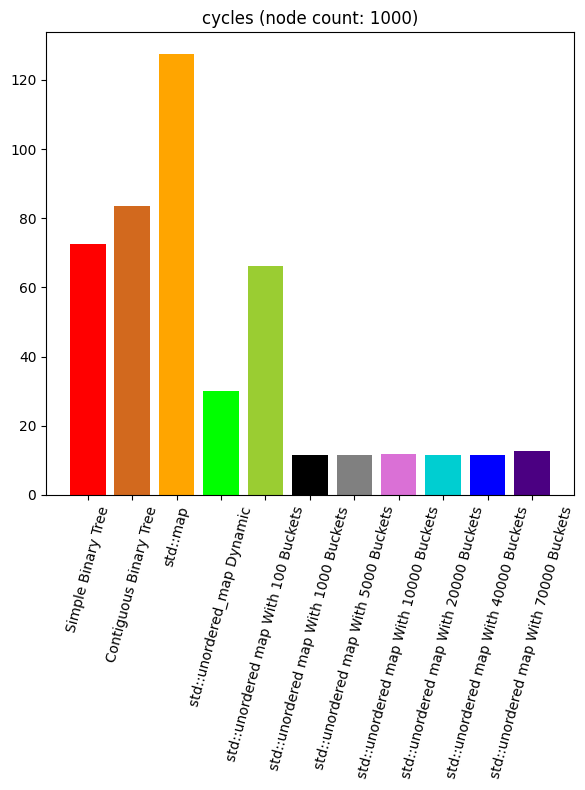

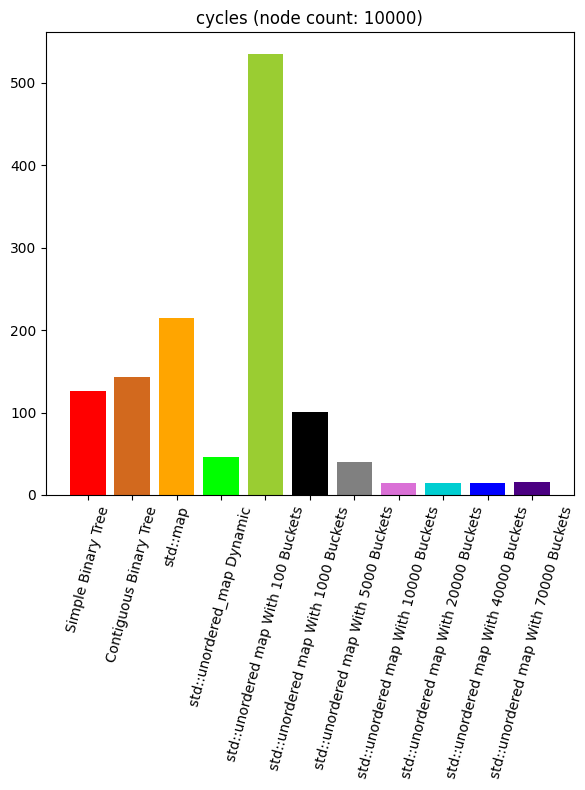

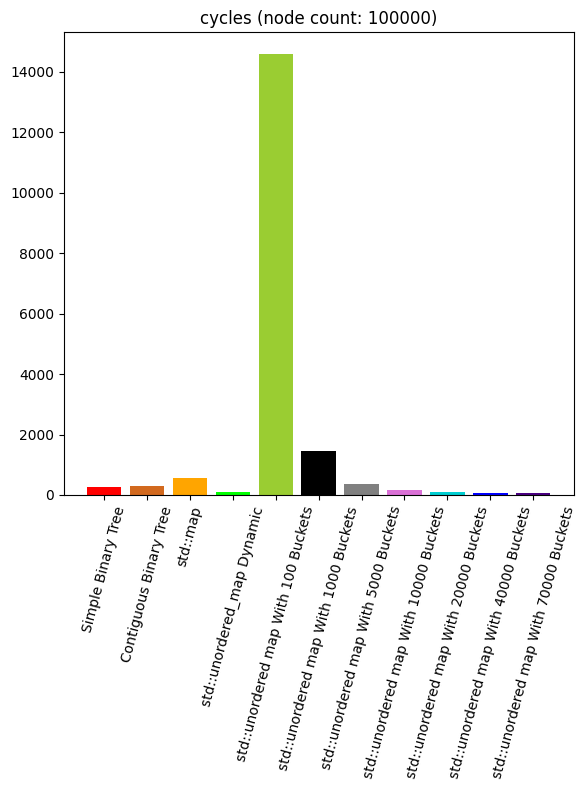

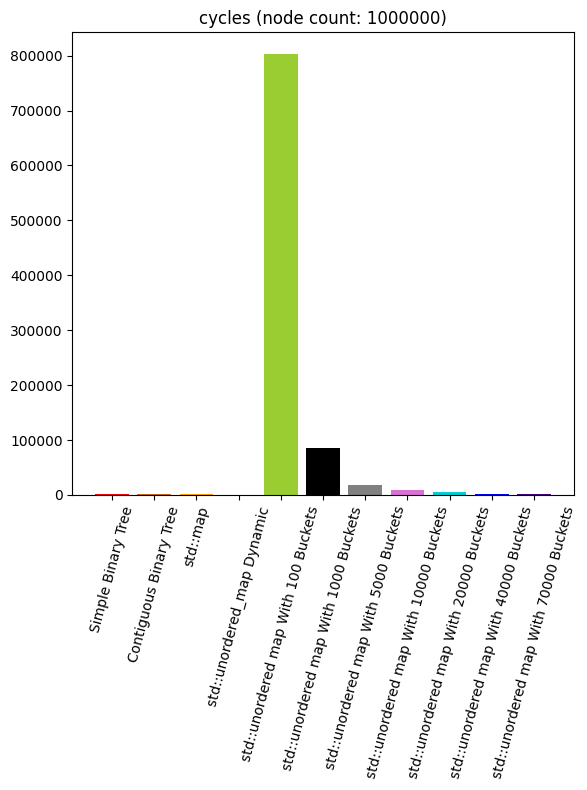

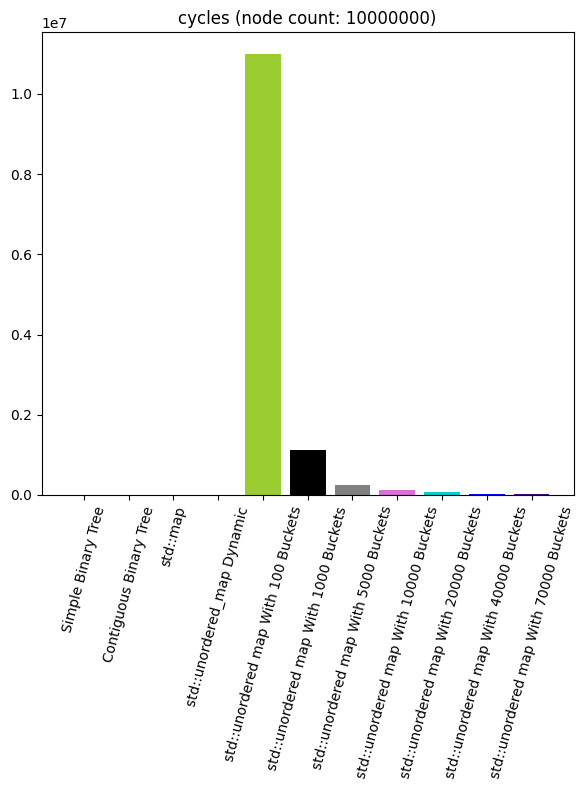

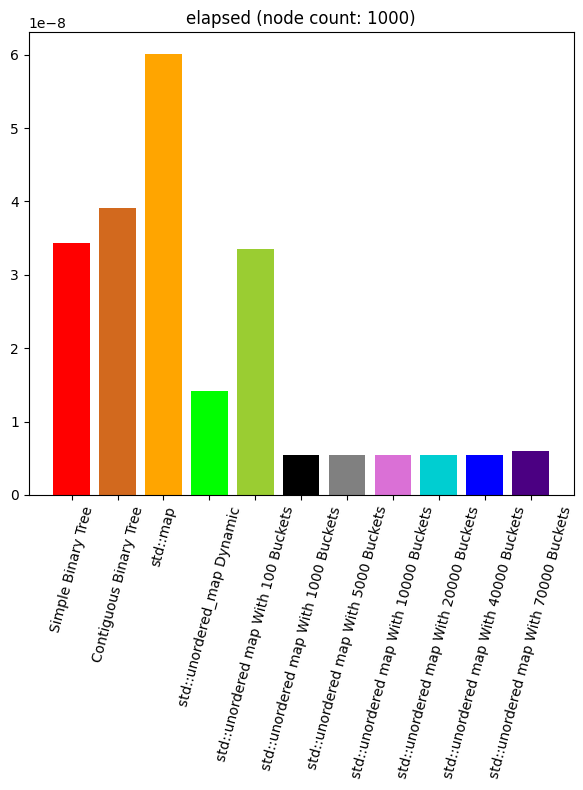

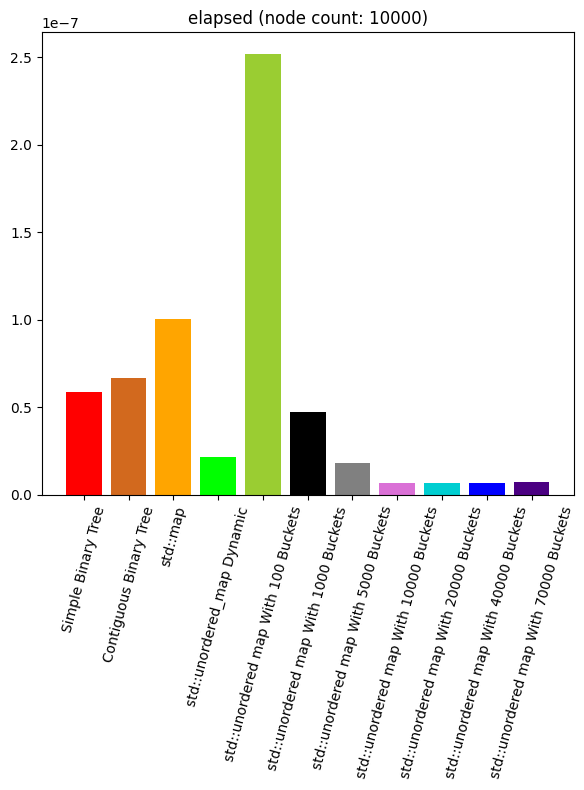

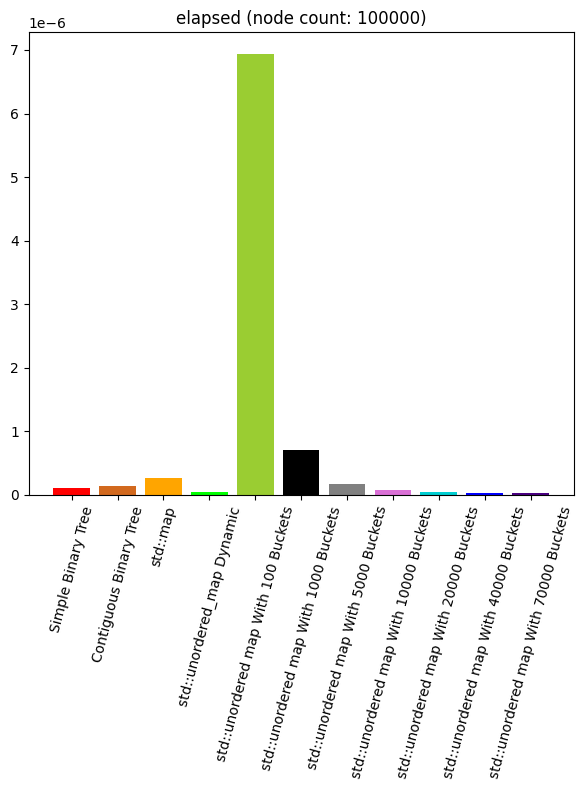

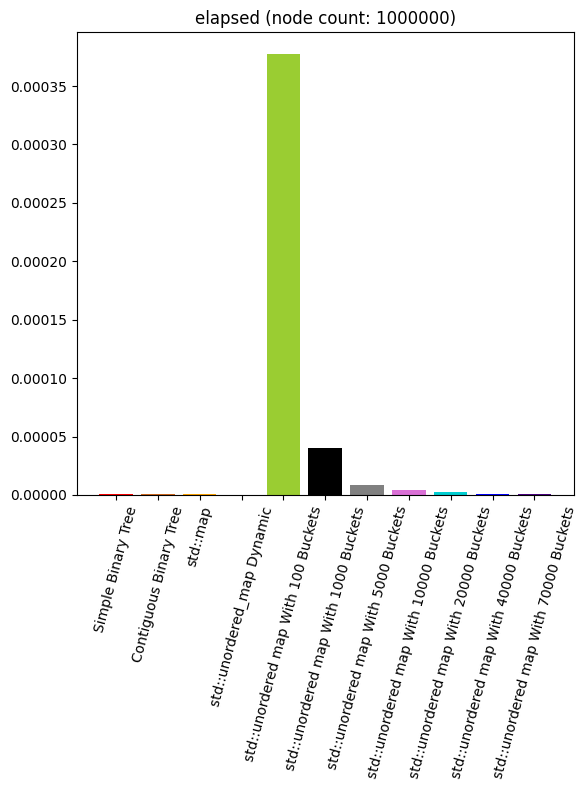

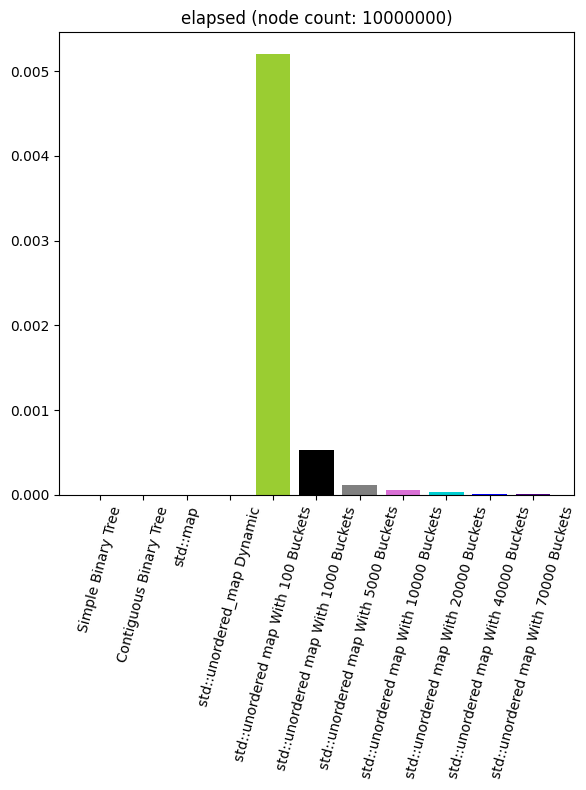

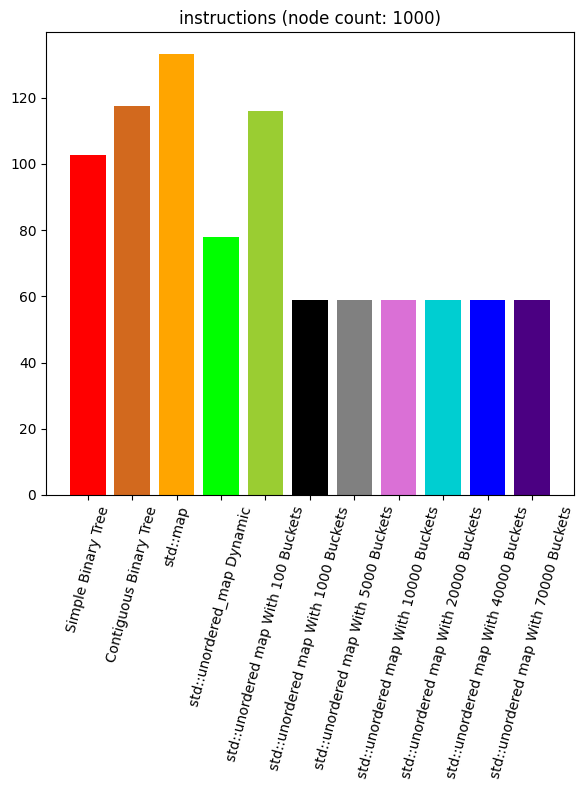

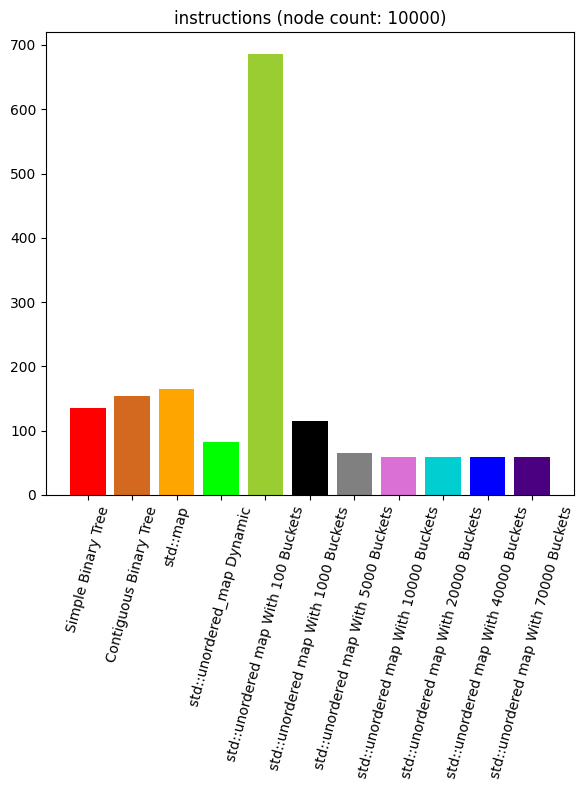

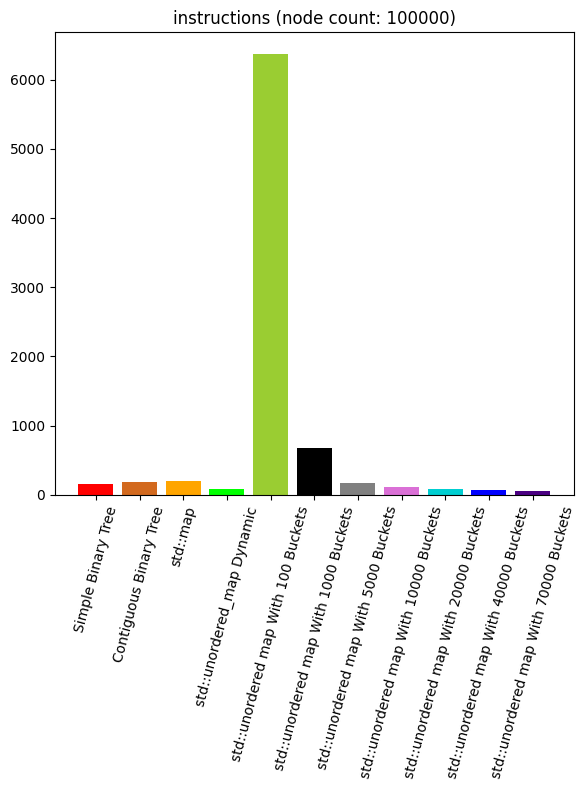

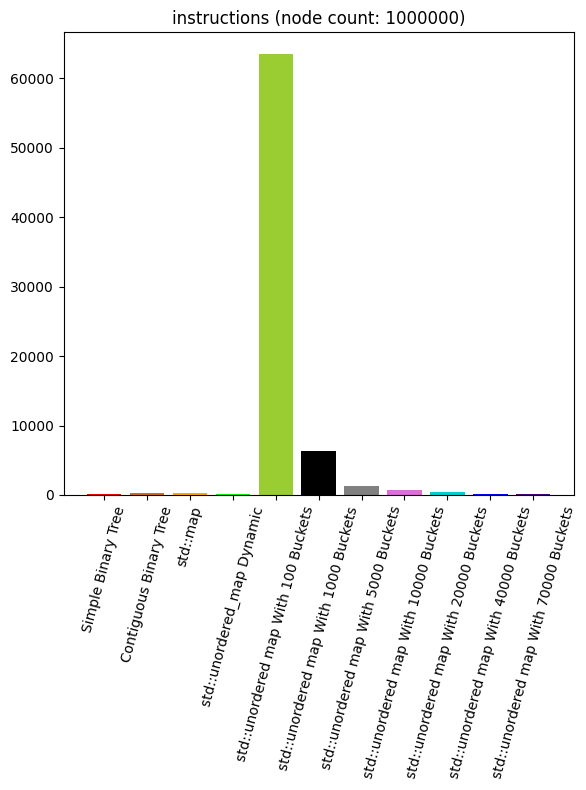

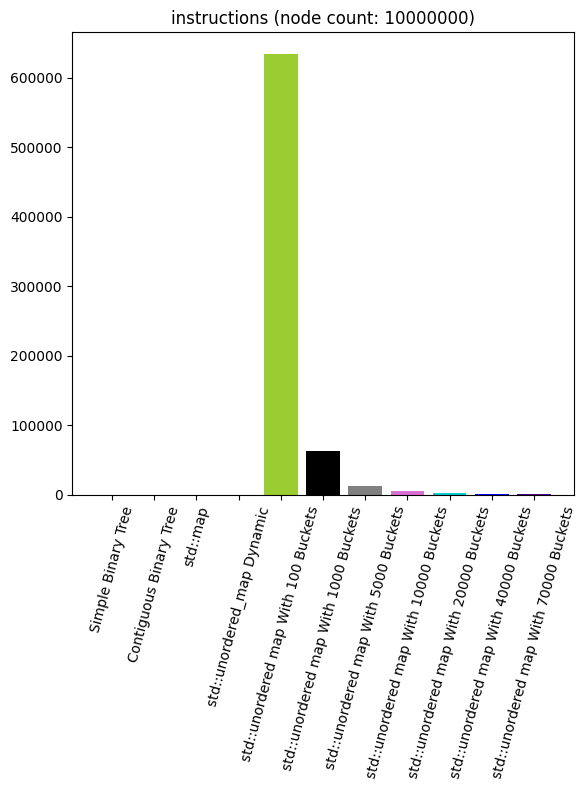

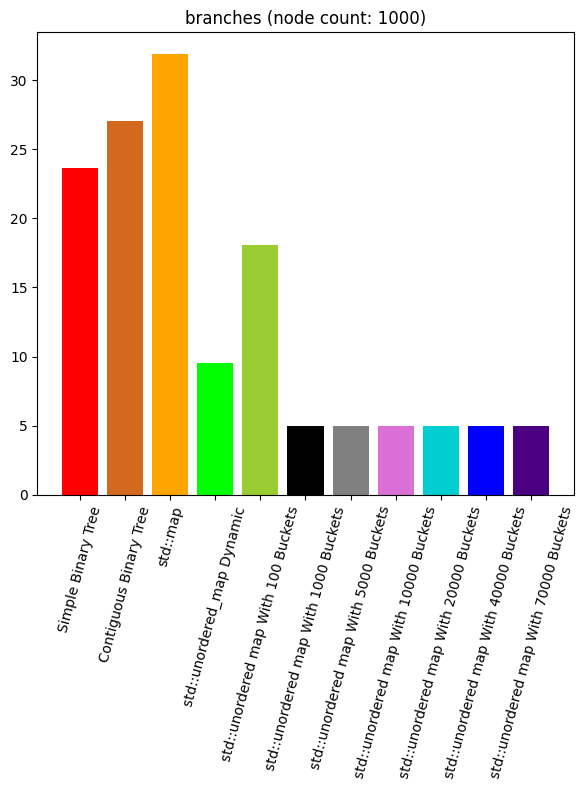

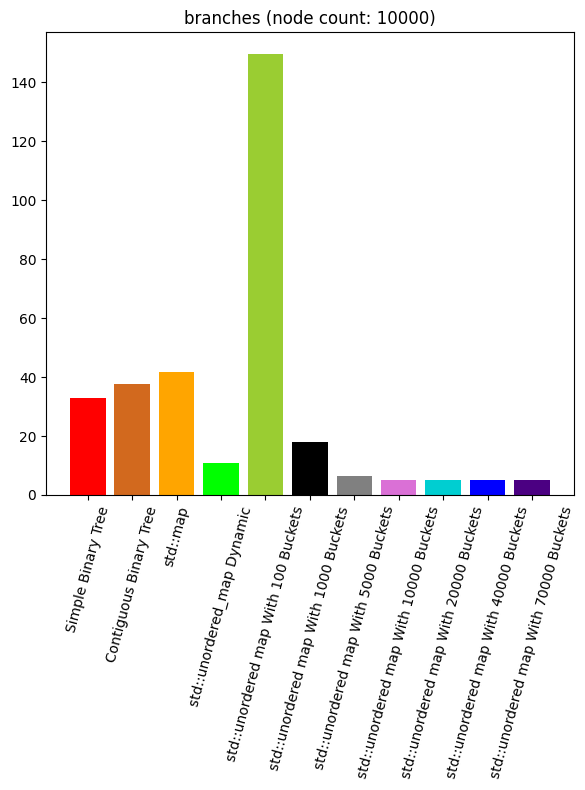

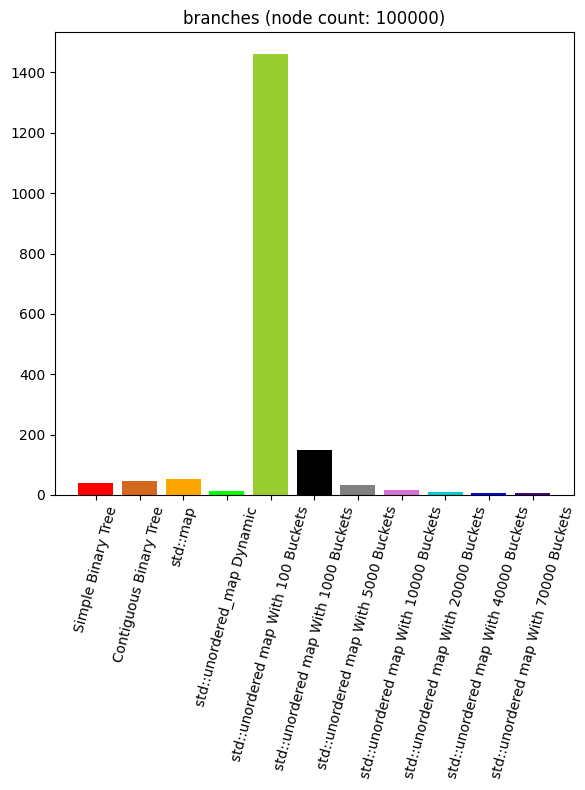

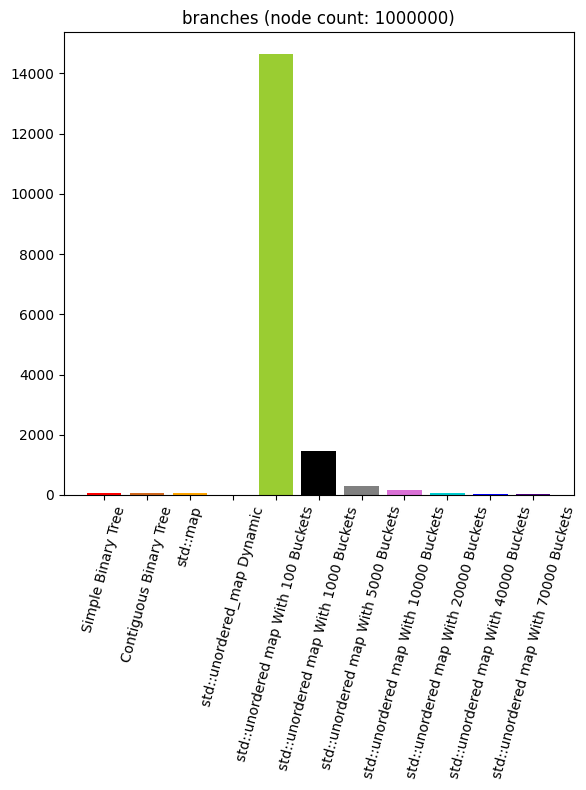

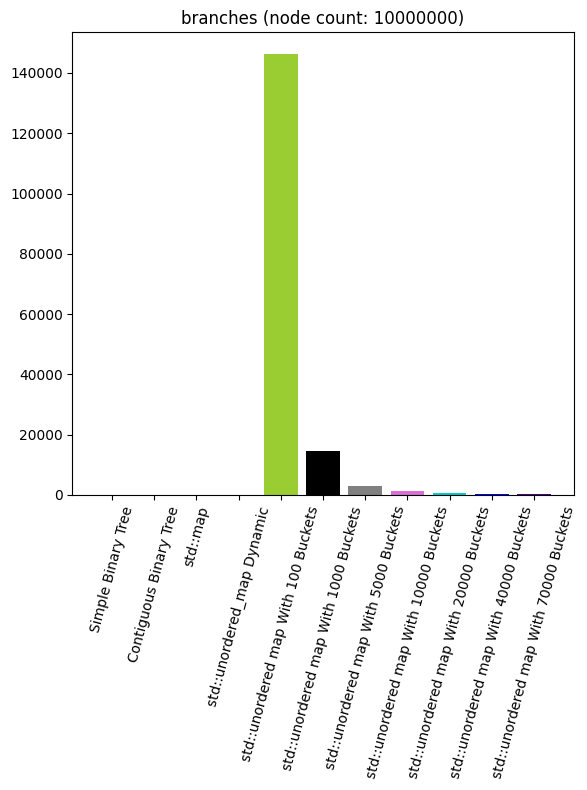

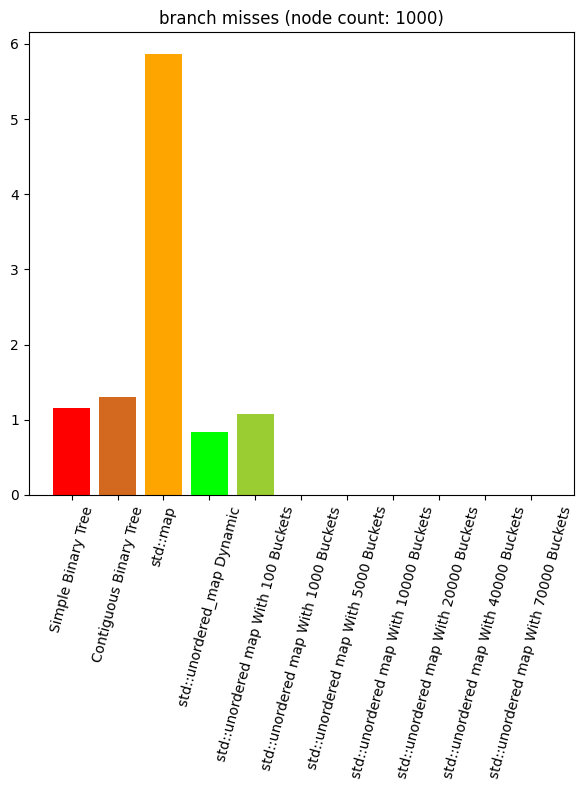

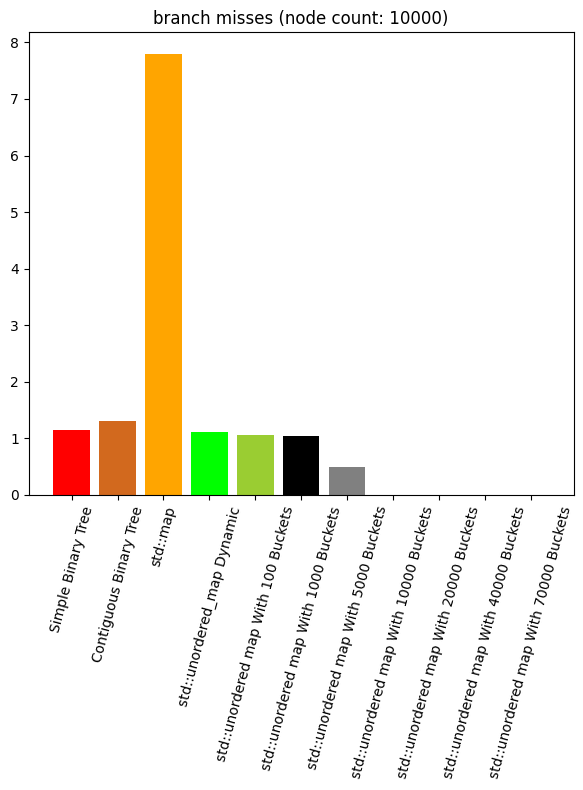

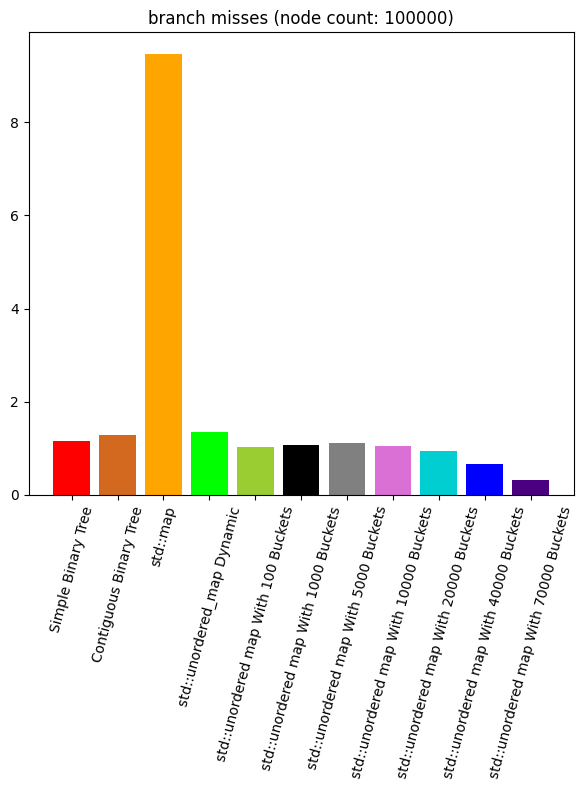

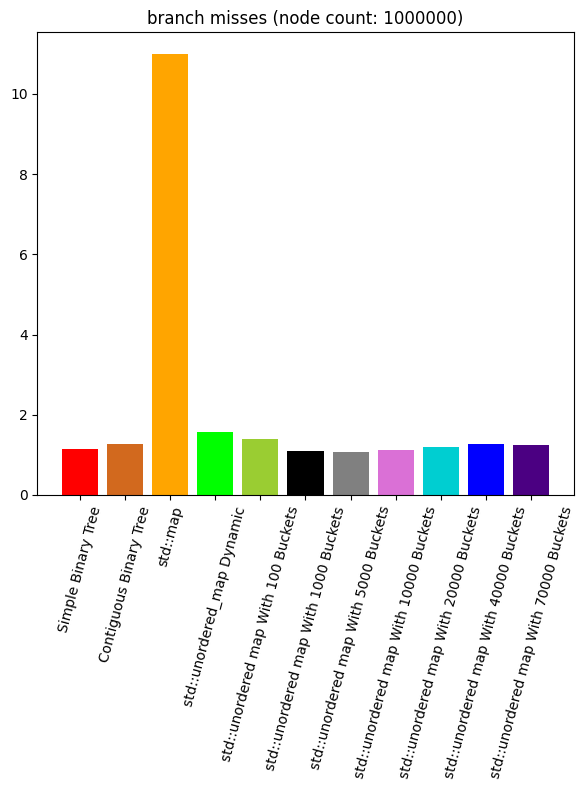

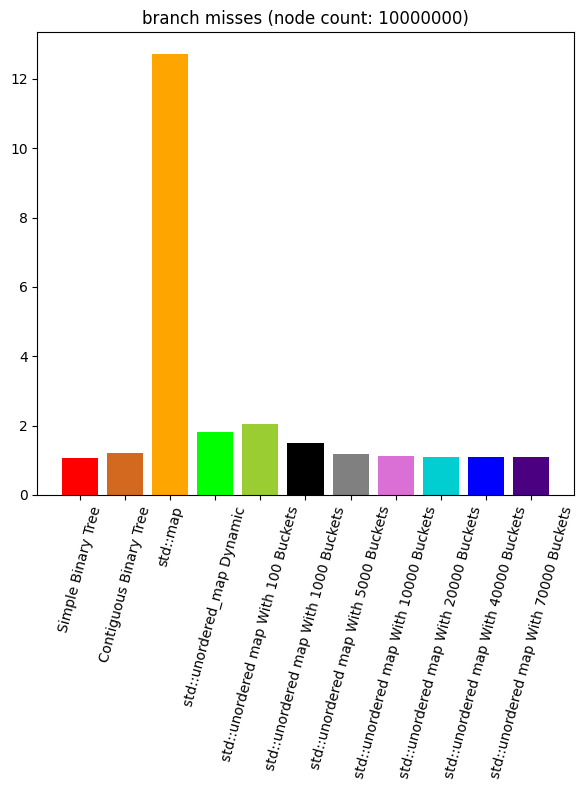

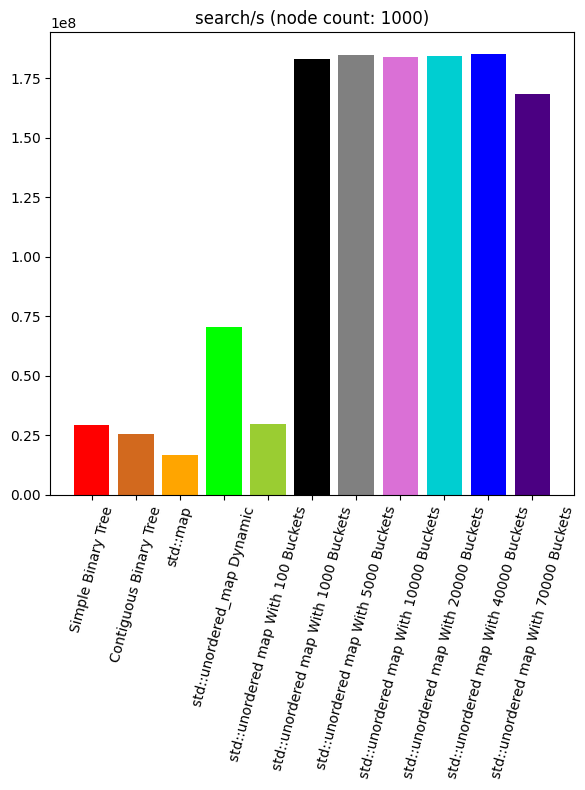

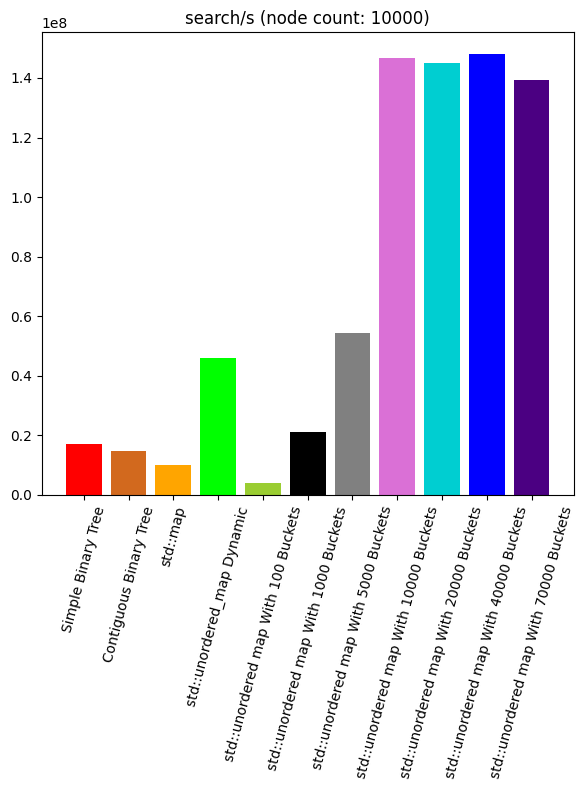

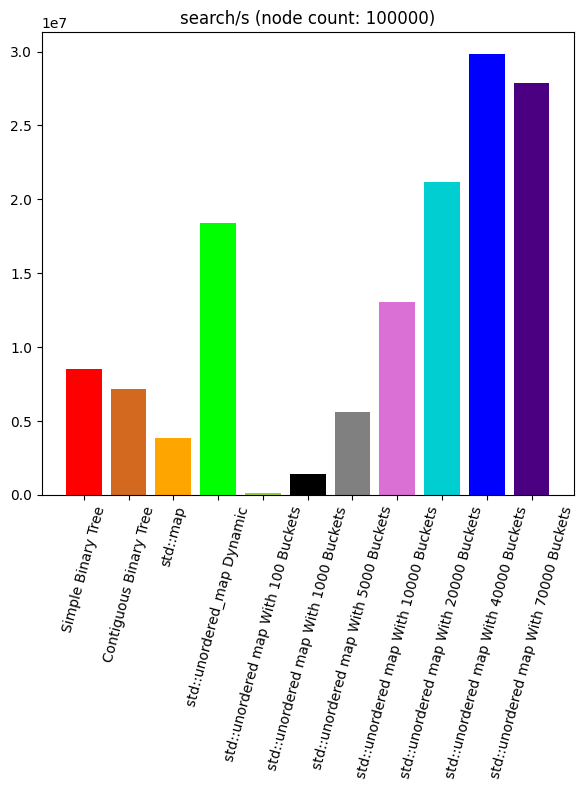

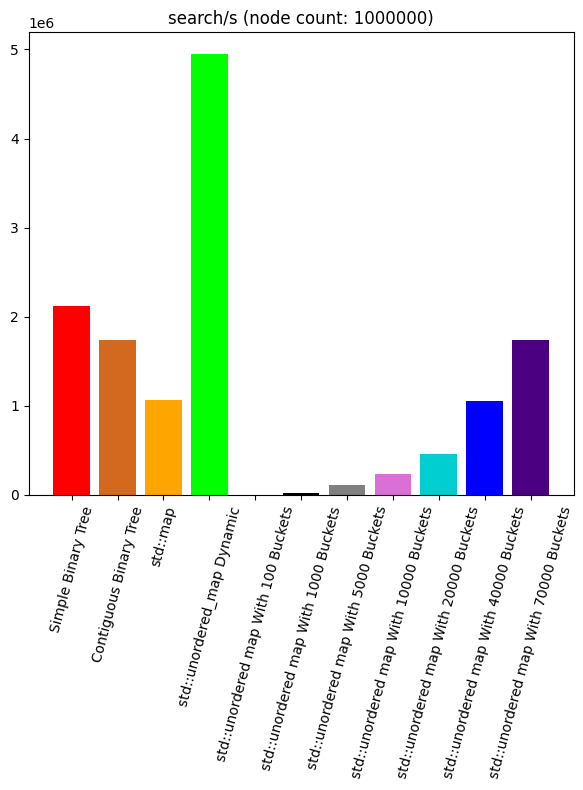

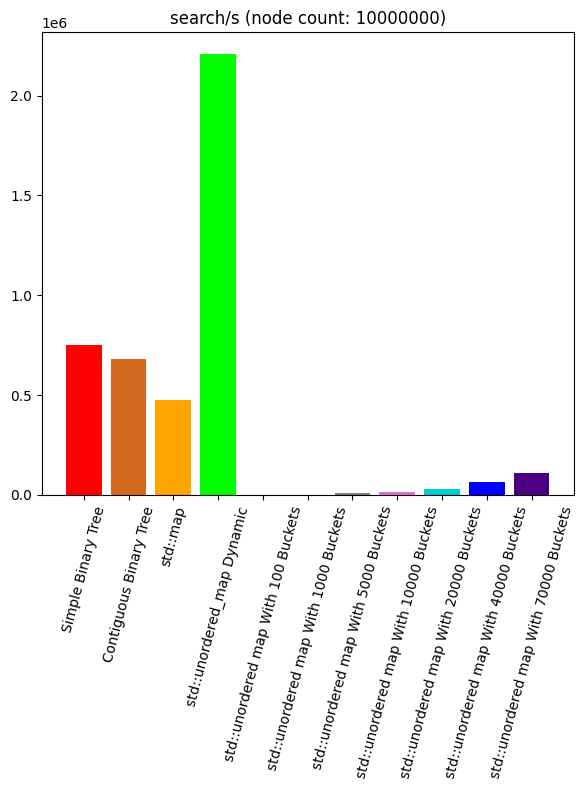

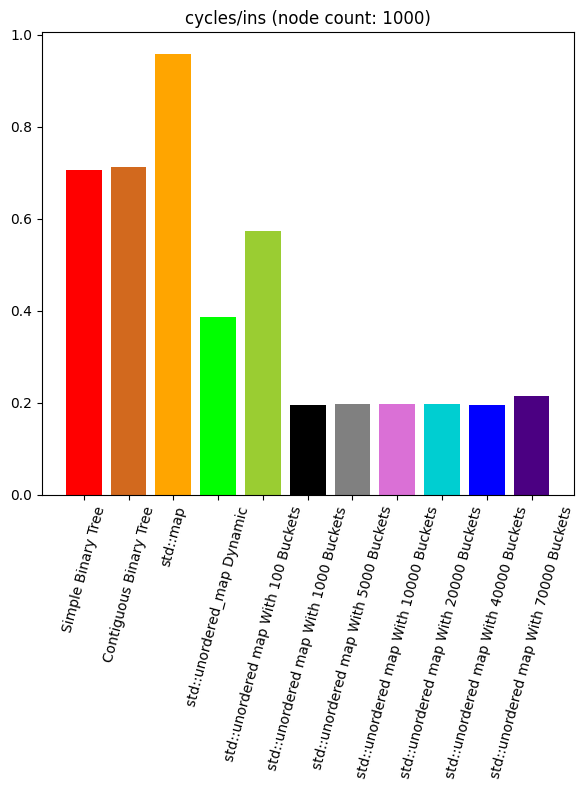

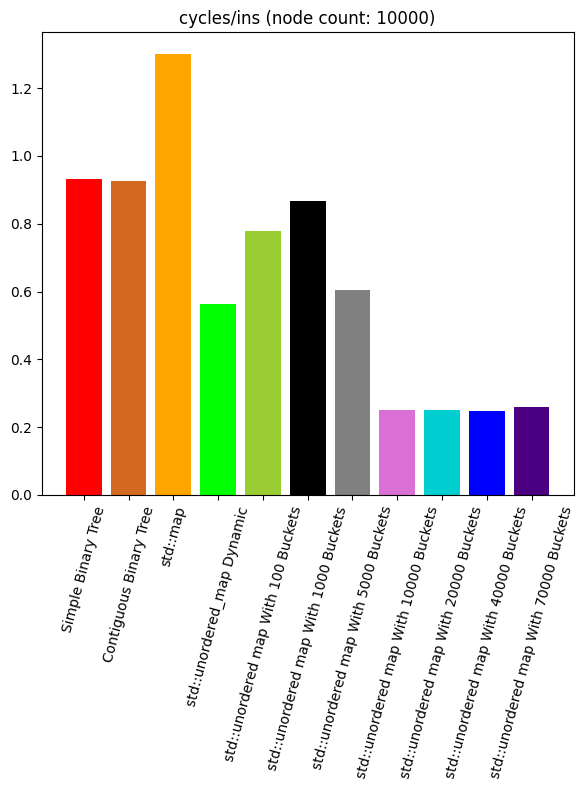

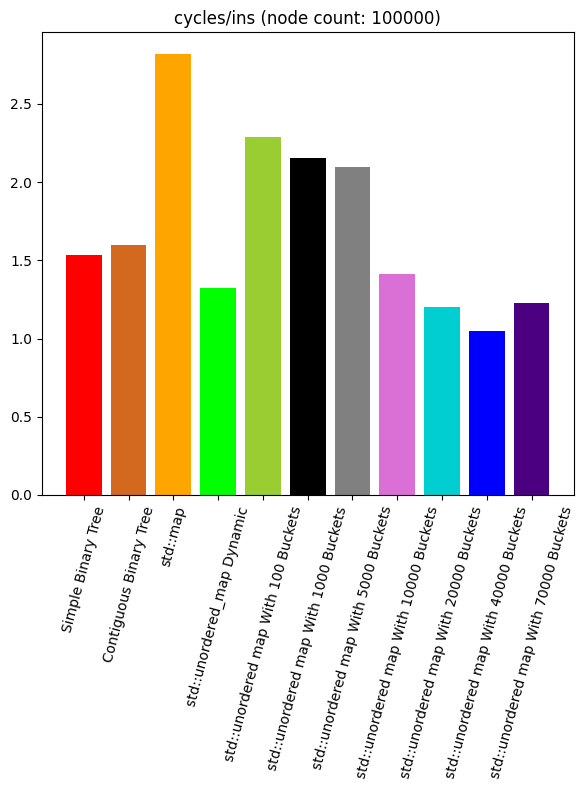

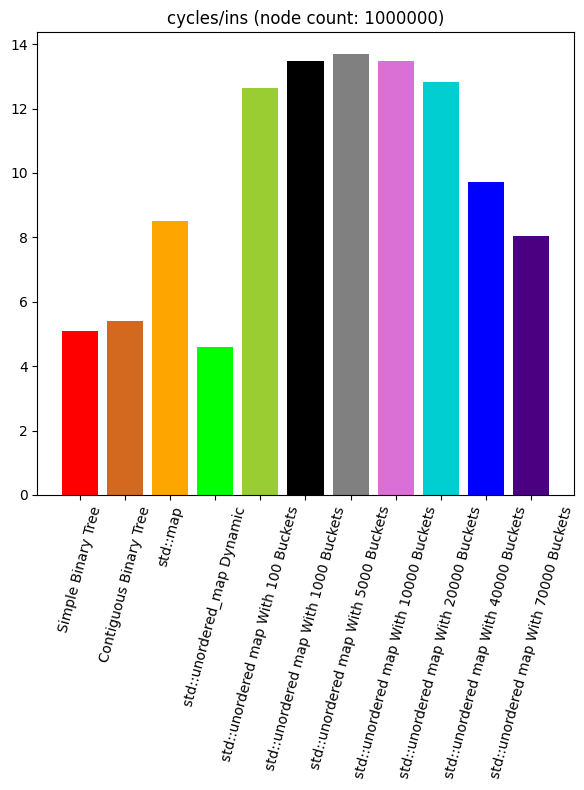

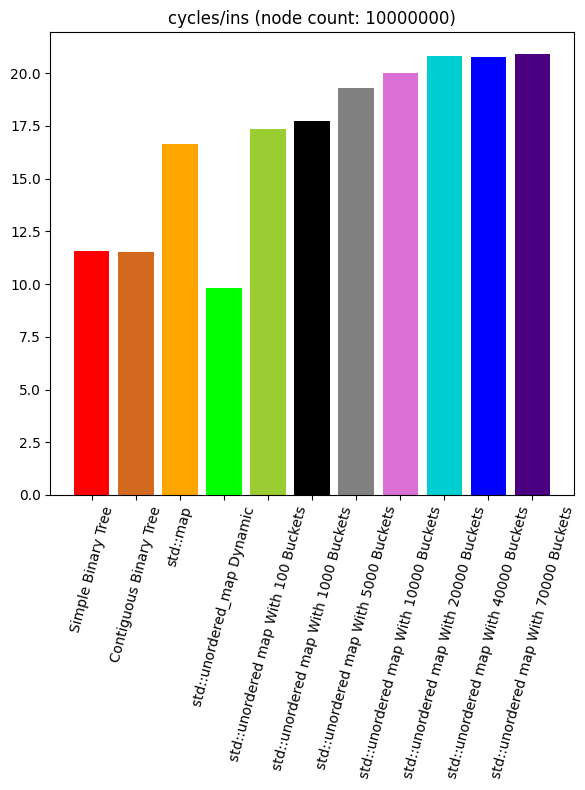

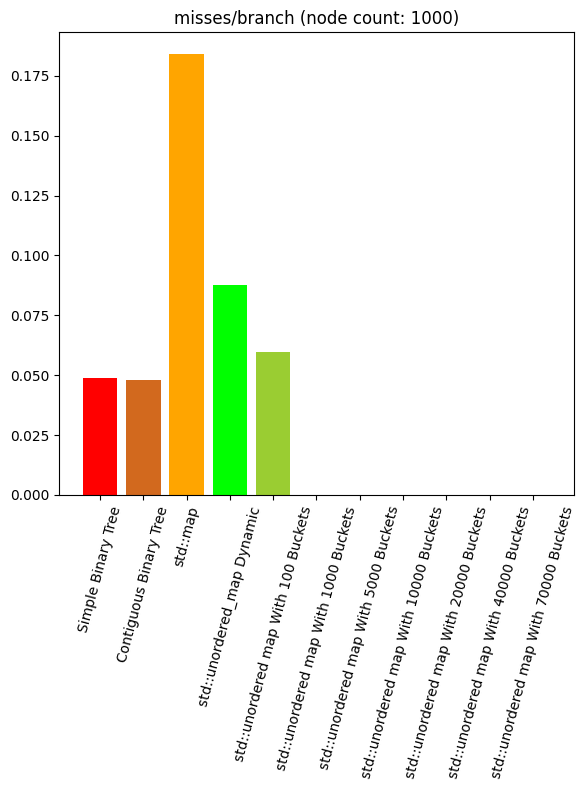

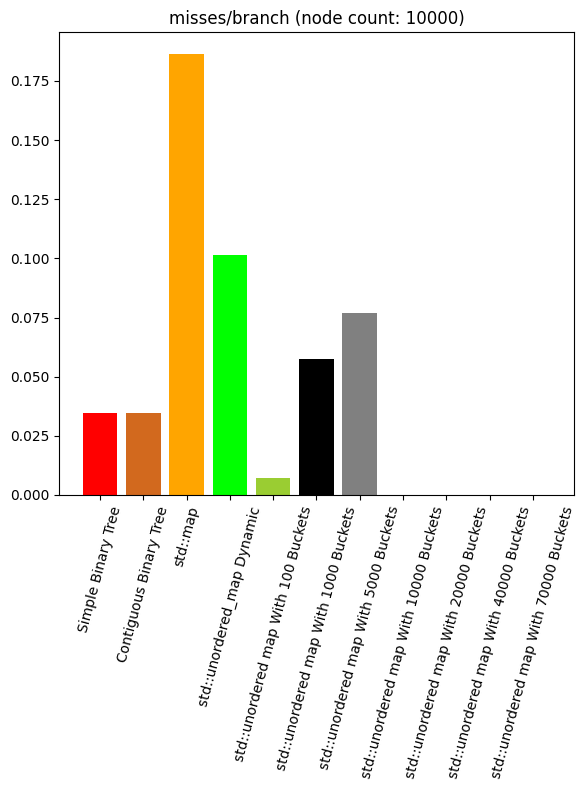

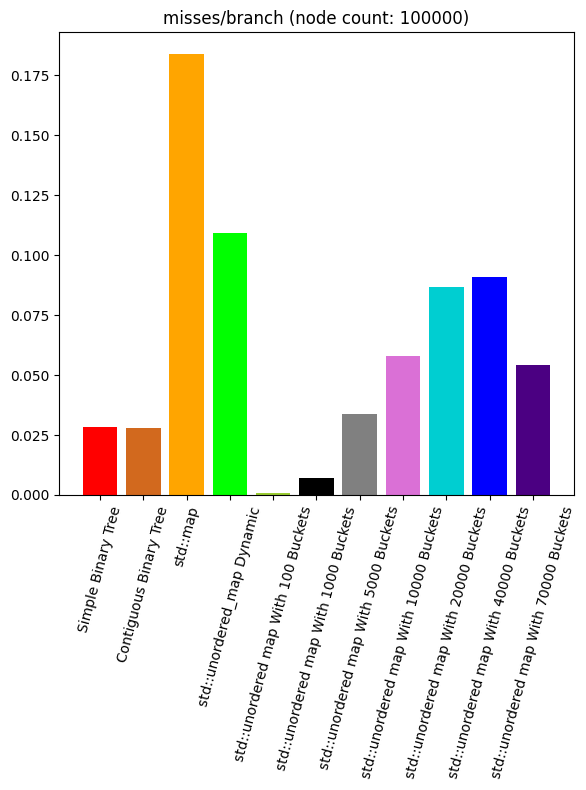

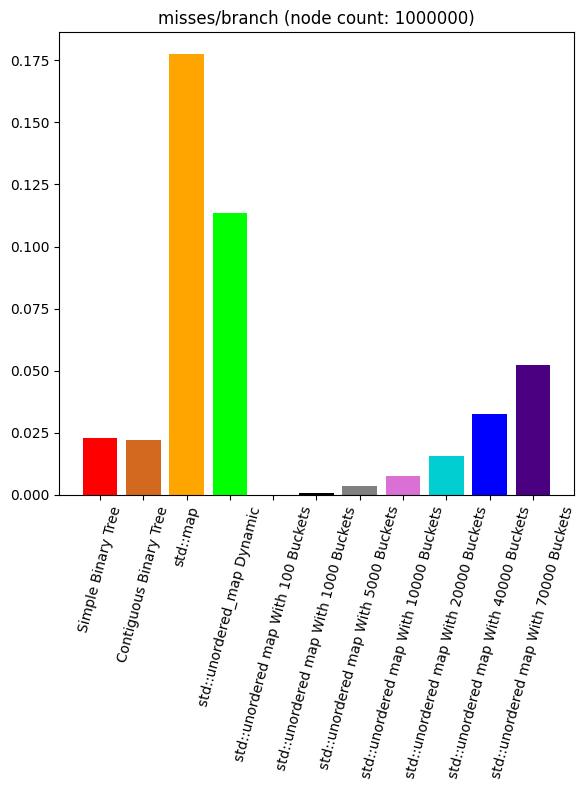

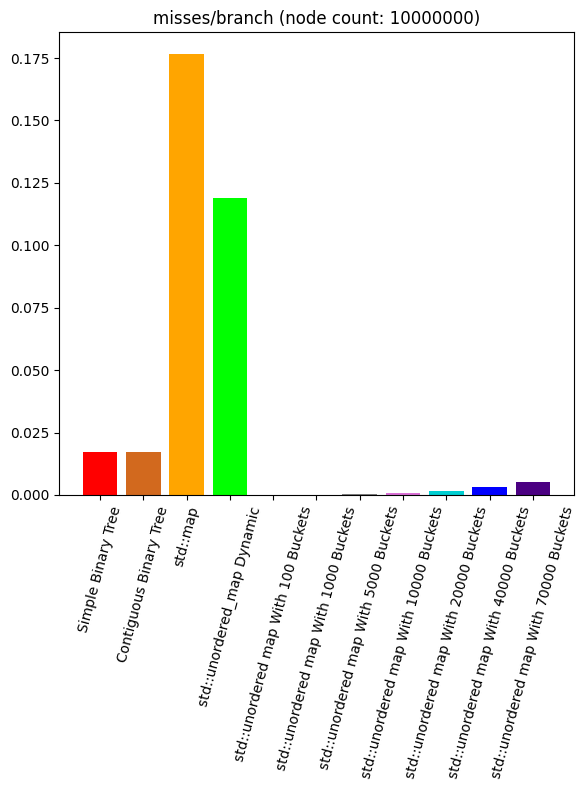

In [8]:
for a in valid_attributes:
    for b in node_counts:
        show_plot(node_counts[b], a)

In [9]:
names = ["Simple Binary Tree",
        "Contiguous Binary Tree",
        'std::map',
        'std::unordered_map Dynamic',
        "std::unordered map With 100 Buckets",
        "std::unordered map With 1000 Buckets",
        "std::unordered map With 5000 Buckets",
        "std::unordered map With 10000 Buckets",
        "std::unordered map With 20000 Buckets",
        "std::unordered map With 40000 Buckets",
        "std::unordered map With 70000 Buckets"
        ]
for name in test_names:
    data = []
    for r in test_results:
        result = test_results[r]
        for n in result:
            if n==name:
                f = [r]
                f+=result[n].get_array()
                data.append(f)
    frame = pd.DataFrame(data)
    frame.columns =["Nodes", "elapsed", "search/s", "instructions", "cycles", "cycles/ins", "branches", "branch misses", "misses/branch"]
    print(names[test_names.index(name)]+":")
    display(frame)

Simple Binary Tree:


,Nodes,elapsed,search/s,instructions,cycles,cycles/ins,branches,branch misses,misses/branch
0,1000,3.427458e-08,2.917614e+07,102.785523,72.682329,0.707126,23.653022,1.155964,0.048872
1,10000,5.891518e-08,1.697355e+07,135.377227,126.190191,0.932138,32.964932,1.149369,0.034866
2,100000,1.173728e-07,8.519864e+06,162.428208,249.452678,1.535772,40.693813,1.160470,0.028517
3,1000000,4.726596e-07,2.115688e+06,195.497930,992.625215,5.077421,50.142351,1.156322,0.023061
4,10000000,1.333370e-06,7.499793e+05,236.032083,2729.714110,11.565013,61.724336,1.071421,0.017358


Contiguous Binary Tree:


,Nodes,elapsed,search/s,instructions,cycles,cycles/ins,branches,branch misses,misses/branch
0,1000,3.916635e-08,2.553212e+07,117.469174,83.646732,0.712074,27.032030,1.297485,0.047998
1,10000,6.698975e-08,1.492766e+07,154.706531,143.402543,0.926933,37.671273,1.307186,0.034700
2,100000,1.393964e-07,7.173785e+06,185.632236,296.278390,1.596050,46.507213,1.291515,0.027770
3,1000000,5.755121e-07,1.737583e+06,223.426288,1204.710302,5.391981,57.305625,1.272271,0.022202
4,10000000,1.463927e-06,6.830941e+05,269.750490,3106.788457,11.517267,70.541845,1.203090,0.017055


std::map:


...

,Nodes,elapsed,search/s,instructions,cycles,cycles/ins,branches,branch misses,misses/branch
0,1000,5.426845e-09,1.842691e+08,59.000009,11.651648,0.197486,5.000005,0.000014,0.000003
1,10000,6.891297e-09,1.451106e+08,59.000010,14.845007,0.251610,5.000006,0.000016,0.000003
2,100000,4.723969e-08,2.116864e+07,84.027574,101.014819,1.202163,10.775597,0.934885,0.086759
3,1000000,2.192916e-06,4.560139e+05,365.372424,4684.804782,12.821999,75.702966,1.200855,0.015863
4,10000000,3.101795e-05,3.223940e+04,3182.715080,66259.746748,20.818623,725.880413,1.085353,0.001495


std::unordered map With 40000 Buckets:


,Nodes,elapsed,search/s,instructions,cycles,cycles/ins,branches,branch misses,misses/branch
0,1000,5.407252e-09,1.849368e+08,59.000007,11.601655,0.196638,5.000002,0.000013,0.000003
1,10000,6.760227e-09,1.479240e+08,59.000010,14.567762,0.246911,5.000006,0.000016,0.000003
2,100000,3.354845e-08,2.980764e+07,68.596986,71.932770,1.048629,7.214686,0.654750,0.090752
3,1000000,9.437248e-07,1.059631e+06,207.136374,2010.413392,9.705748,39.185944,1.279602,0.032655
4,10000000,1.577713e-05,6.338289e+04,1598.671589,33196.636219,20.765138,360.320806,1.083626,0.003007


std::unordered map With 70000 Buckets:


,Nodes,elapsed,search/s,instructions,cycles,cycles/ins,branches,branch misses,misses/branch
0,1000,5.939181e-09,1.683734e+08,59.000009,12.752772,0.216149,5.000005,0.000014,0.000003
1,10000,7.179683e-09,1.392819e+08,59.000010,15.350045,0.260170,5.000005,0.000015,0.000003
2,100000,3.590328e-08,2.785261e+07,62.531140,76.610767,1.225162,5.814875,0.315988,0.054341
3,1000000,5.761556e-07,1.735642e+06,141.690495,1137.582263,8.028642,24.082564,1.257039,0.052197
4,10000000,9.285400e-06,1.076960e+05,944.922392,19743.928277,20.894762,209.450579,1.108169,0.005291
